In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("HechosTransitoExamen.csv")
print(df.shape)

(639, 21)


In [3]:
df.columns

Index(['no_folio', 'fecha_evento', 'mes', 'hora', 'tipo_de_evento',
       'coordenada_x', 'coordenada_y', 'punto_1', 'punto_2', 'colonia',
       'alcaldia', 'tipo_de_interseccion', 'tipo_de_vehiculo_1',
       'tipo_de_vehiculo_2', 'edad_lesionado', 'dia', 'edad_occiso',
       'clasificacion_de_la_vialidad', 'sector', 'diagnostico_lesionado',
       'origen'],
      dtype='object')

In [12]:
df['fecha_evento_dt'] = pd.to_datetime(df['fecha_evento'], dayfirst=True)

In [13]:
print(df.shape)

(639, 22)


In [19]:
tabla1 = df['fecha_evento_dt'].value_counts()

In [24]:
tabla1.sort_index(ascending=True)

,count
fecha_evento_dt,
2022-01-02,3
2022-01-03,1
2022-01-04,1
2022-01-06,1
2022-01-08,1
...,...
2022-12-24,2
2022-12-25,1
2022-12-28,2


In [28]:
x= tabla1.index
y= tabla1.values

In [29]:
len(x)

281

In [30]:
len(y)

281

In [34]:
tabla1 = (
    df.groupby('fecha_evento_dt')
      .size()
      .reset_index(name='conteo')
      .sort_values('fecha_evento_dt')
)

In [35]:
tabla1['fecha_evento_dt'].duplicated().sum()

np.int64(0)

In [36]:
import matplotlib.pyplot as plt

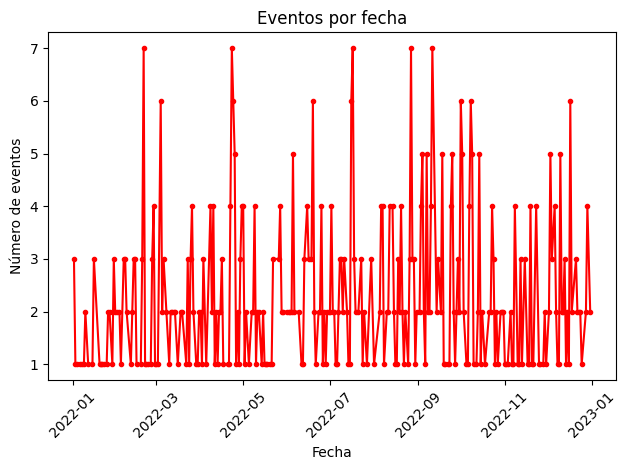

In [42]:
plt.figure()

plt.plot(tabla1['fecha_evento_dt'],tabla1['conteo'],'r.-')

plt.xlabel('Fecha')
plt.ylabel('Número de eventos')
plt.title('Eventos por fecha')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [44]:
tabla_mensual = (
    df.groupby(df['fecha_evento_dt'].dt.to_period('M'))
      .size()
      .reset_index(name='accidentes_mes')
)

In [50]:
tabla_mensual['accidentes_mes']

,accidentes_mes
0,30
1,46
2,47
3,64
4,43
5,57
6,59
7,62
8,69
9,64


In [52]:
tabla_mensual['mes'] = tabla_mensual['fecha_evento_dt'].dt.to_timestamp()

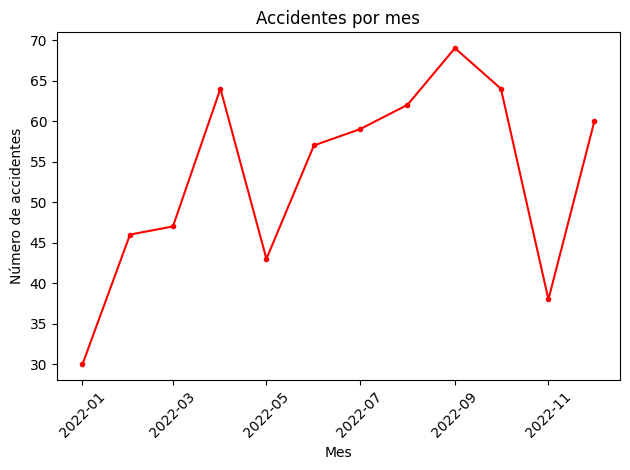

In [53]:
plt.figure()

plt.plot(tabla_mensual['mes'], tabla_mensual['accidentes_mes'],'r.-')

plt.xlabel('Mes')
plt.ylabel('Número de accidentes')
plt.title('Accidentes por mes')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()